# Notebook to review the Kenya Met Hindcasts 

Looking at the hindcasts checking the occurrence of events.

In [10]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import ocha_stratus as stratus
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns

import re
from utils import parser, helpers
from utils.constants import *
from src.datasources.era5 import fetch_era5_data

In [12]:
import calendar

season_months = [10, 11, 12]
start_date = pd.Timestamp("1997-01-01")
end_date = pd.Timestamp("2025-12-31")

In [13]:
iso3 = "KEN"
blob_name_jul = "ds-aa-ken-drought/raw/July_hindcast.txt"
blob_name_aug = "ds-aa-ken-drought/raw/Aug_hincasts.txt"
blob_name_sep = "ds-aa-ken-drought/raw/September_Hindcasts.txt"

In [ ]:
ken_adm = stratus.codab.load_codab_from_fieldmaps(iso3, admin_level=1)
ken_adm0 = stratus.codab.load_codab_from_fieldmaps(iso3, admin_level=0)
# jul_hindcast = (
#    stratus.load_blob_data(blob_name_jul, stage="dev", container_name="projects")
#    .decode("utf-8")
#    .splitlines()
# )
# aug_hindcast = (
#    stratus.load_blob_data(blob_name_aug, stage="dev", container_name="projects")
#    .decode("utf-8")
#    .splitlines()
# )
# sep_hindcast = (
#    stratus.load_blob_data(blob_name_sep, stage="dev", container_name="projects")
#    .decode("utf-8")
#    .splitlines()
# )

In [ ]:
#dfs = parser.parse_cpt_lines(jul_hindcast)
#final_df_jul = pd.concat(dfs, axis=0)
#upload_blob_name = "ds-aa-ken-drought/processed/july_cleaned_hindcasts.parquet"
#stratus.upload_parquet_to_blob(
#    final_df_jul, upload_blob_name, stage="dev", container_name="projects"
#)

In [ ]:
#dfs = parser.parse_cpt_lines(aug_hindcast)
#final_df_aug = pd.concat(dfs, axis=0)
#upload_blob_name = "ds-aa-ken-drought/processed/august_cleaned_hindcasts.parquet"
#stratus.upload_parquet_to_blob(
#    final_df_aug, upload_blob_name, stage="dev", container_name="projects"
#)

In [ ]:
#dfs = parser.parse_cpt_lines(sep_hindcast)
#final_df_sep = pd.concat(dfs, axis=0)
#upload_blob_name = "ds-aa-ken-drought/processed/september_cleaned_hindcasts.parquet"
#stratus.upload_parquet_to_blob(
#    final_df_sep, upload_blob_name, stage="dev", container_name="projects"
#)

In [ ]:
#final_df_jul["issue_month"] = "July"
#final_df_aug["issue_month"] = "August"
#final_df_sep["issue_month"] = "September"
#final_df = pd.concat([final_df_jul, final_df_aug, final_df_sep], axis=0)
#upload_blob_name = "ds-aa-ken-drought/processed/cleaned_hindcasts.parquet"
#stratus.upload_parquet_to_blob(
#    final_df, upload_blob_name, stage="dev", container_name="projects"
#)
#final_df.head(3)

,lat,lon,value,C,T,clim_prob,clim_prob_type,issue_month
0,5.75,33.25,38.599842,1,2005-10-01,0.2004542,below,July
1,5.75,33.75,37.861221,1,2005-10-01,0.2004542,below,July
2,5.75,34.25,37.609367,1,2005-10-01,0.2004542,below,July


In [16]:
final_df = stratus.load_parquet_from_blob(
    "ds-aa-ken-drought/processed/cleaned_hindcasts.parquet",
    stage="dev",
    container_name="projects",
)

In [17]:
# dissolve adm to these areas
arid_union = ken_adm[ken_adm["adm1_name"].isin(arid)].dissolve().reset_index(drop=True)

NameError: name 'ken_adm0' is not defined

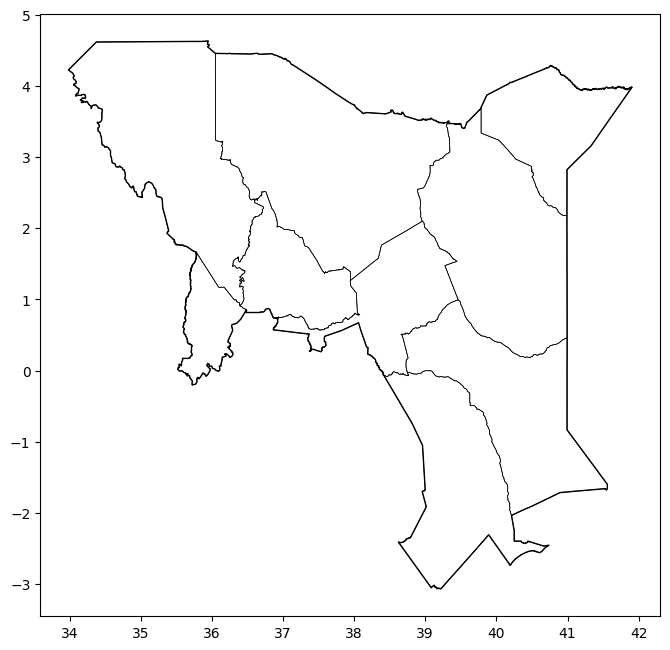

In [18]:
interest_year = 2005
df = final_df[
    (final_df["C"] == "1")
    & (final_df["clim_prob_type"] == "below")
    & (final_df["issue_month"] == "July")
    & (final_df["T"] == f"{interest_year}-10-01")
].copy()

gdf_points = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs=ken_geo_epsg
)

gdf_points["geometry"] = gdf_points.geometry.to_crs(ken_epsg).buffer(
    cell_size / 2, cap_style=3
)

gdf_points = gdf_points.to_crs(ken_geo_epsg)

gdf_points["color"] = gdf_points["value"].apply(
    lambda v: "#C28C64" if v > 35 else "#A6D7C2"
)

fig, ax = plt.subplots(figsize=(8, 10))
ken_adm[ken_adm["adm1_name"].isin(arid)].boundary.plot(
    ax=ax, color="black", linewidth=0.5
)
arid_union.boundary.plot(ax=ax, color="black", linewidth=1)
ken_adm0.boundary.plot(ax=ax, color="black", linewidth=1.5)

gdf_points.plot(
    ax=ax,
    column="value",
    cmap="YlOrBr",
    legend=True,
    edgecolor="none",
    vmin=20,
    vmax=70,
)
# gdf_points.plot(ax=ax, color=gdf_points["color"], edgecolor="none")
ax.set_title(
    f"Probability of SPI being below -0.84\nfor July issued forecasts targetting OND {interest_year}",
    fontsize=14,
)
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

NameError: name 'ken_adm0' is not defined

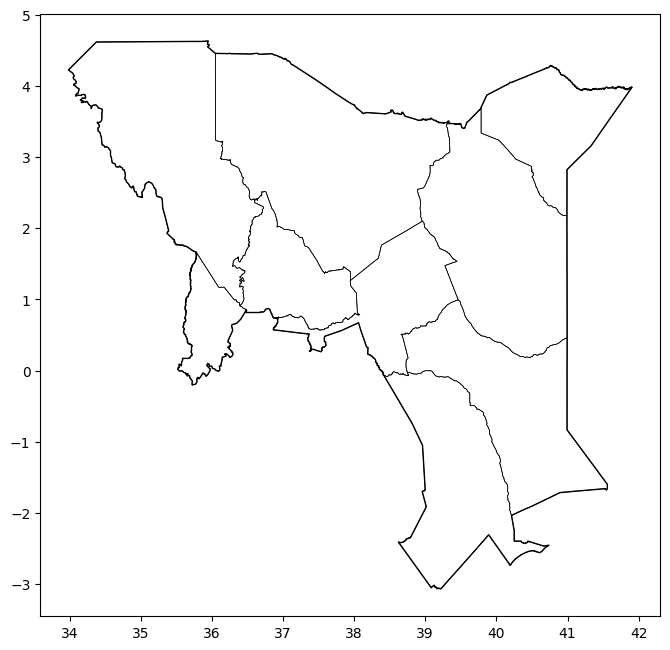

In [19]:
df = final_df[
    (final_df["C"] == "2")
    & (final_df["clim_prob_type"] == "below")
    & (final_df["issue_month"] == "July")
    & (final_df["T"] == f"{interest_year}-10-01")
].copy()

gdf_points = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs=ken_geo_epsg
)

gdf_points["geometry"] = gdf_points.geometry.to_crs(ken_epsg).buffer(
    cell_size / 2, cap_style=3
)

gdf_points = gdf_points.to_crs(ken_geo_epsg)
arid_union = arid_union.to_crs(ken_geo_epsg)
intersecting = gpd.sjoin(gdf_points, arid_union, how="inner", predicate="intersects")

fig, ax = plt.subplots(figsize=(8, 10))
ken_adm[ken_adm["adm1_name"].isin(arid)].boundary.plot(
    ax=ax, color="black", linewidth=0.5
)
arid_union.boundary.plot(ax=ax, color="black", linewidth=1)
ken_adm0.boundary.plot(ax=ax, color="black", linewidth=1.5)

intersecting.plot(
    ax=ax,
    column="value",
    cmap="YlOrBr",
    legend=True,
    edgecolor="none",
    vmin=20,
    vmax=50,
)

ax.set_title(
    f"Probability of SPI being below -0.43\nfor July issued forecasts targetting OND {interest_year}",
    fontsize=14,
)
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

Now, looking at the 1-in-5 yr clim prob

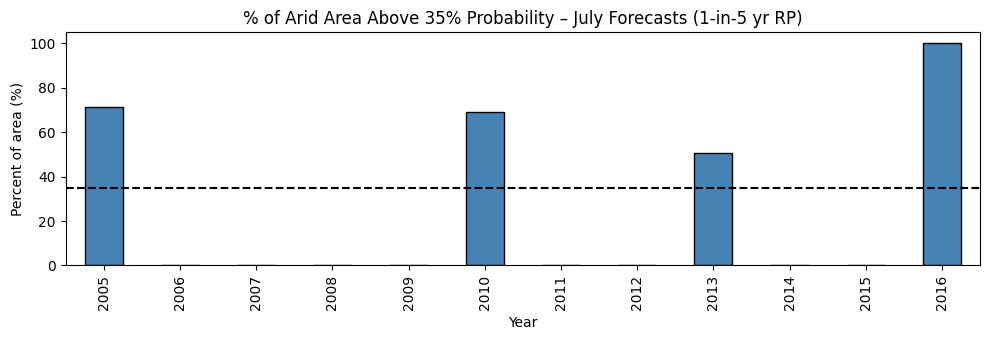

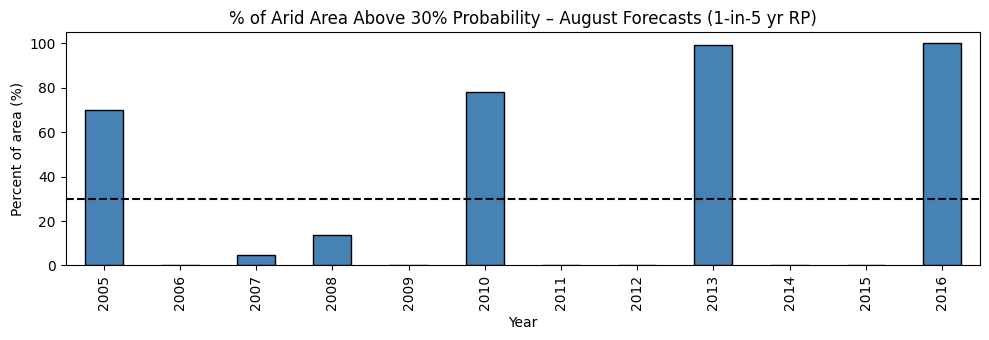

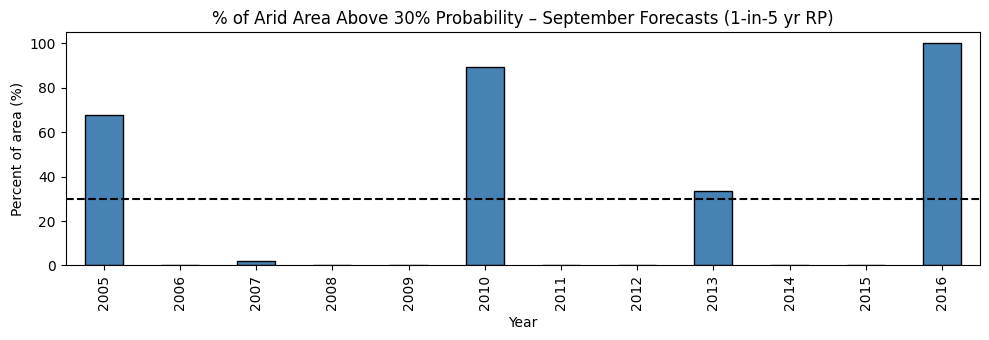

In [20]:
for issue_month in issue_months:

    df = final_df[
        (final_df["C"] == "1")
        & (final_df["clim_prob_type"] == "below")
        & (final_df["issue_month"] == issue_month)
    ].copy()

    # build geodf
    gdf_points = gpd.GeoDataFrame(
        df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs=ken_geo_epsg
    )

    # build square pixel polygons
    gdf_points = gdf_points.to_crs(ken_epsg)
    gdf_points["geometry"] = gdf_points.geometry.buffer(cell_size / 2, cap_style=3)
    gdf_points = gdf_points.to_crs(ken_geo_epsg)

    gdf_points["year"] = pd.to_datetime(gdf_points["T"]).dt.year

    # clip to arid region (Keeps only the inside portion of each pixel)
    arid_union = arid_union.to_crs(ken_geo_epsg)
    clipped = gpd.clip(gdf_points, arid_union)

    # project to meters for area calculation
    clipped_m = clipped.to_crs(ken_epsg)
    clipped_m["area"] = clipped_m.geometry.area

    # month-specific threshold
    thr = thresholds_RP5[issue_month]
    clipped_m["above"] = clipped_m["value"] > thr
    # area-based summary
    summary = clipped_m.groupby("year").apply(
        lambda g: pd.Series(
            {
                "total_area": g["area"].sum(),
                "area_above": g.loc[g["above"], "area"].sum(),
                "pct_area_above": 100
                * g.loc[g["above"], "area"].sum()
                / g["area"].sum(),
            }
        ),
        include_groups=False,
    )

    # plot
    fig, ax = plt.subplots(figsize=(10, 3.5))

    summary["pct_area_above"].plot.bar(ax=ax, color="steelblue", edgecolor="black")

    ax.set_title(
        f"% of Arid Area Above {thr}% Probability – {issue_month} Forecasts (1-in-5 yr RP)"
    )
    ax.set_xlabel("Year")
    ax.set_ylabel("Percent of area (%)")

    # reference threshold line (area plot, not probability)
    ax.axhline(y=thr, color="black", linestyle="--")

    plt.tight_layout()
    plt.show()

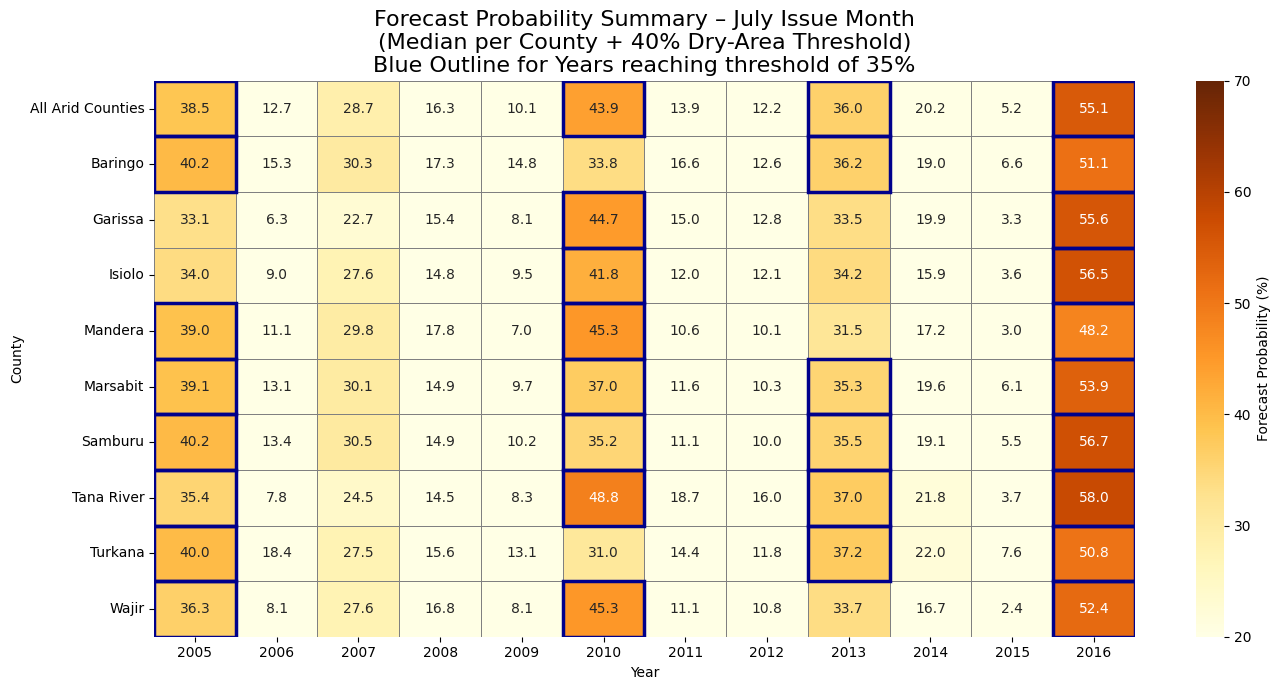

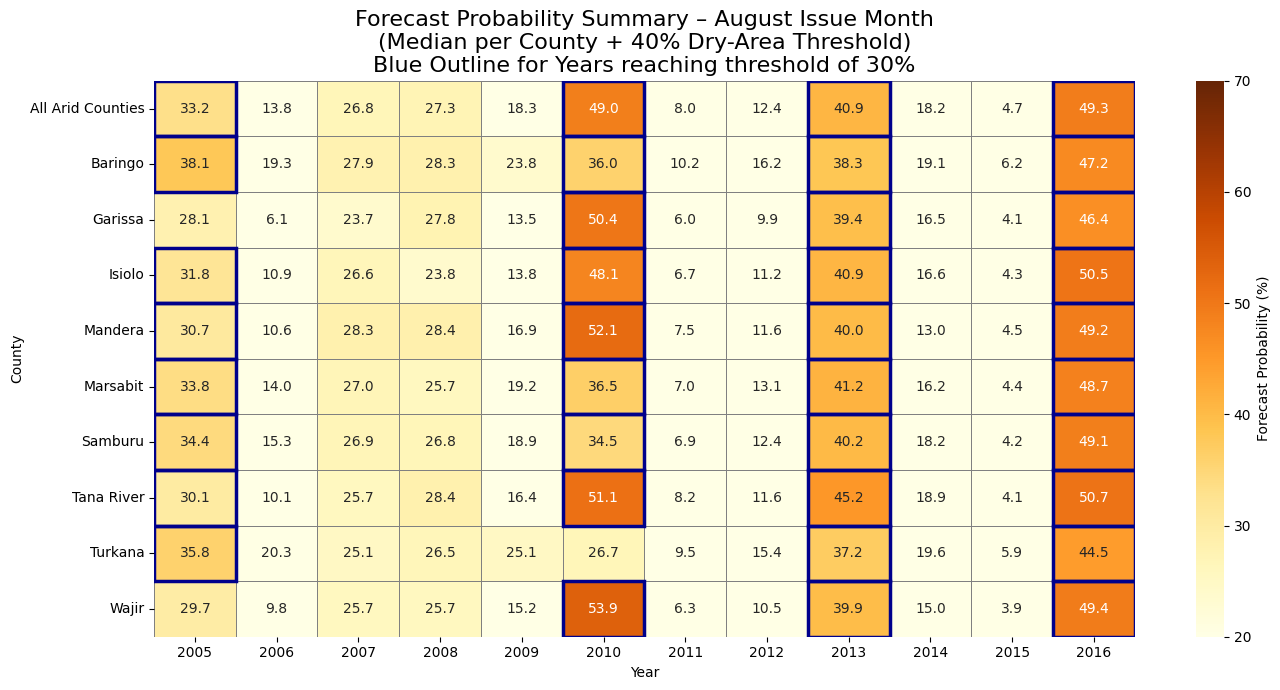

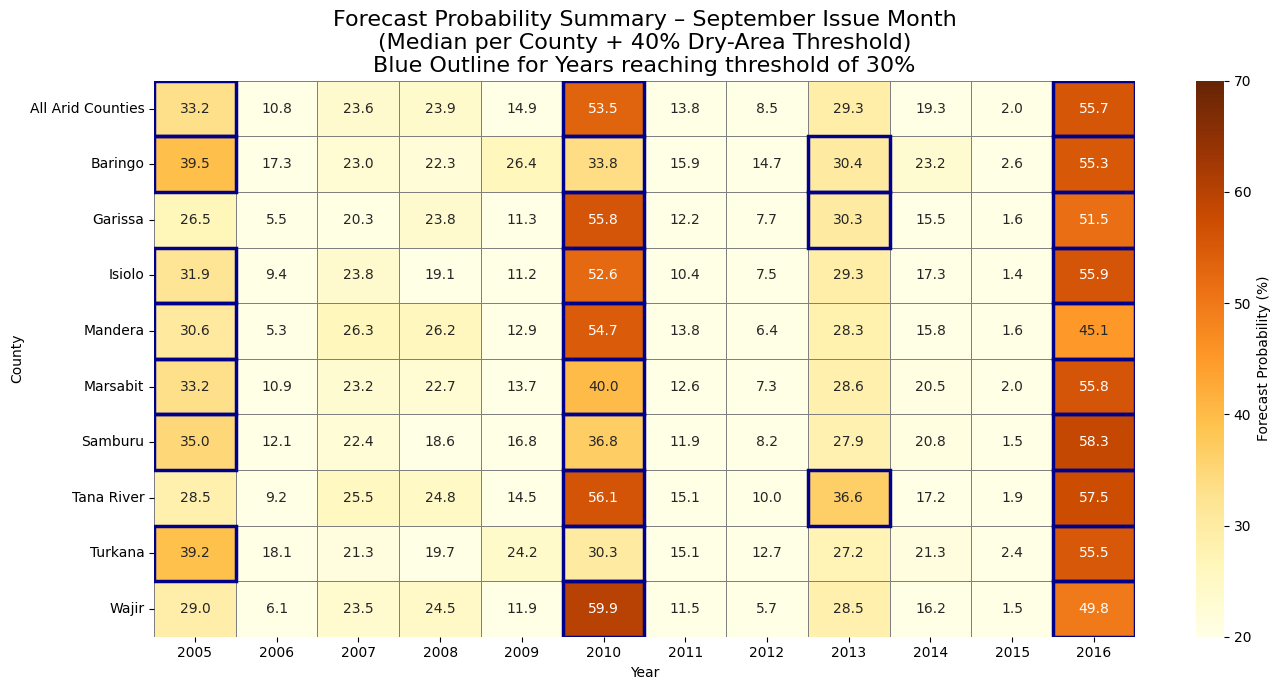

In [21]:
arid_counties = ken_adm[ken_adm["adm1_name"].isin(arid)].to_crs(ken_geo_epsg)

for issue_month in issue_months:

    df = final_df[
        (final_df["C"] == "1")
        & (final_df["clim_prob_type"] == "below")
        & (final_df["issue_month"] == issue_month)
    ].copy()

    gdf_points = gpd.GeoDataFrame(
        df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs=ken_geo_epsg
    )
    gdf_points = gdf_points.to_crs(ken_epsg)
    gdf_points["geometry"] = gdf_points.geometry.buffer(cell_size / 2, cap_style=3)
    gdf_points = gdf_points.to_crs(ken_geo_epsg)
    gdf_points["year"] = pd.to_datetime(gdf_points["T"]).dt.year

    # Spatial join with counties
    joined = gpd.sjoin(gdf_points, arid_counties, how="inner", predicate="intersects")

    # ------- 1) COUNTY-LEVEL median forecast probability -------
    avg_prob = joined.groupby(["adm1_name", "year"])["value"].median().reset_index()

    heat = avg_prob.pivot_table(index="adm1_name", columns="year", values="value")

    # ------- 2) ALL-ARID-AREA: Probability threshold for driest 40% -------
    # Compute 0.60 quantile for each year over ALL intersecting pixels
    q = (
        joined.groupby("year")["value"]
        .quantile(1 - quantile_RP5)
        .rename("All Arid Counties")
        .to_frame()
        .T  # put it as a row
    )

    # ------- 3) ADD to heatmap -------
    heat_with_row = pd.concat([q, heat], axis=0)

    # ------- 4) Plot -------
    plt.figure(figsize=(14, 7))
    sns.heatmap(
        heat_with_row,
        cmap="YlOrBr",
        linewidths=0.5,
        linecolor="gray",
        cbar_kws={"label": "Forecast Probability (%)"},
        annot=True,
        fmt=".1f",
        vmin=20,
        vmax=70,
    )
    threshold = thresholds_RP5.get(issue_month)

    plt.title(
        f"Forecast Probability Summary – {issue_month} Issue Month\n"
        f"(Median per County + {round(100*(quantile_RP5))}% Dry-Area Threshold)\nBlue Outline for Years reaching threshold of {threshold}%",
        fontsize=16,
    )
    plt.xlabel("Year")
    plt.ylabel("County")

    ax = plt.gca()
    for i, county in enumerate(heat_with_row.index):
        for j, year in enumerate(heat_with_row.columns):
            val = heat_with_row.loc[county, year]
            if val >= threshold:
                ax.add_patch(
                    plt.Rectangle(
                        (j, i), 1, 1, fill=False, edgecolor="darkblue", linewidth=2.5
                    )
                )

    plt.tight_layout()
    plt.show()

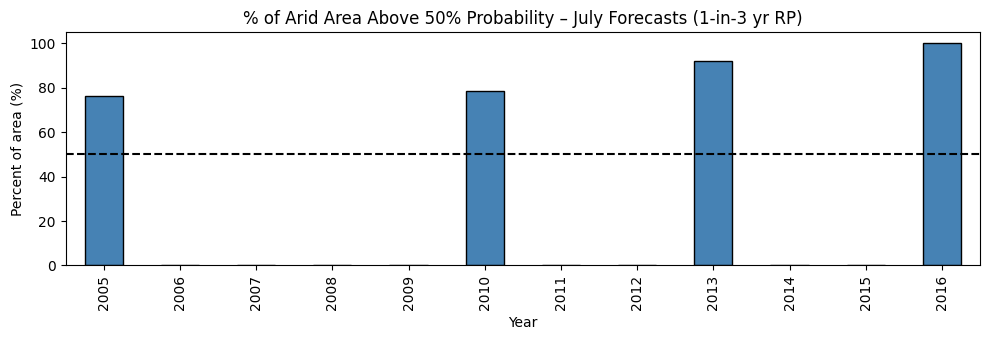

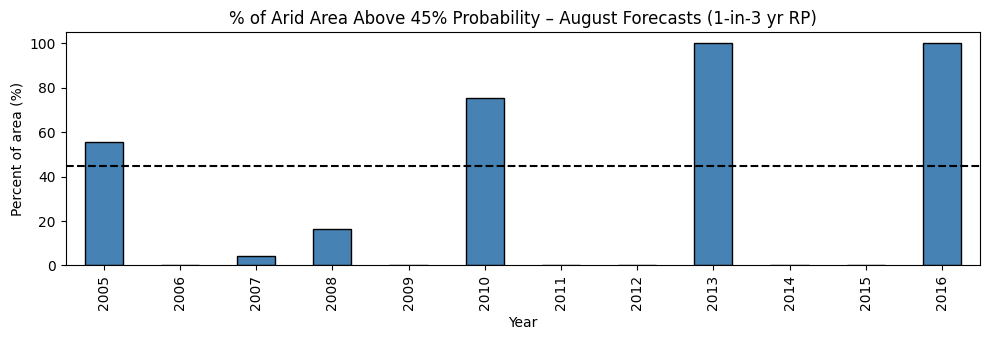

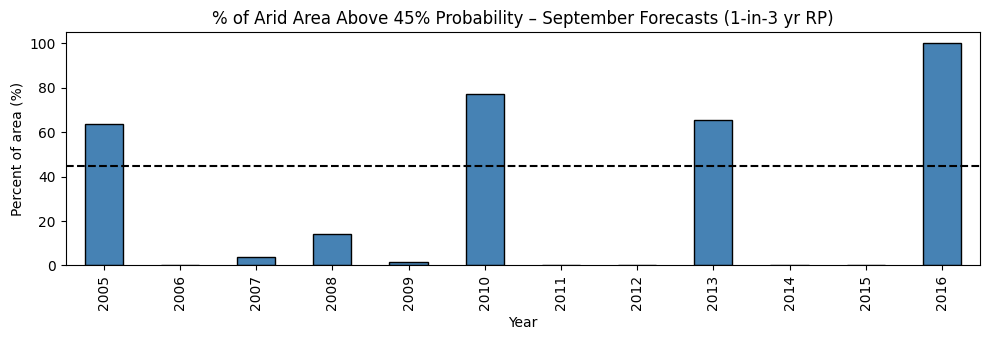

In [22]:
for issue_month in issue_months:

    df = final_df[
        (final_df["C"] == "2")
        & (final_df["clim_prob_type"] == "below")
        & (final_df["issue_month"] == issue_month)
    ].copy()

    # build geodf
    gdf_points = gpd.GeoDataFrame(
        df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs=ken_geo_epsg
    )

    # build square pixel polygons
    gdf_points = gdf_points.to_crs(ken_epsg)
    gdf_points["geometry"] = gdf_points.geometry.buffer(cell_size / 2, cap_style=3)
    gdf_points = gdf_points.to_crs(ken_geo_epsg)

    gdf_points["year"] = pd.to_datetime(gdf_points["T"]).dt.year

    # clip to arid region (Keeps only the inside portion of each pixel)
    arid_union = arid_union.to_crs(ken_geo_epsg)
    clipped = gpd.clip(gdf_points, arid_union)

    # project to meters for area calculation
    clipped_m = clipped.to_crs(ken_epsg)
    clipped_m["area"] = clipped_m.geometry.area

    # month-specific threshold
    thr = thresholds_RP3[issue_month]
    clipped_m["above"] = clipped_m["value"] > thr
    # area-based summary
    summary = clipped_m.groupby("year").apply(
        lambda g: pd.Series(
            {
                "total_area": g["area"].sum(),
                "area_above": g.loc[g["above"], "area"].sum(),
                "pct_area_above": 100
                * g.loc[g["above"], "area"].sum()
                / g["area"].sum(),
            }
        ),
        include_groups=False,
    )

    # plot
    fig, ax = plt.subplots(figsize=(10, 3.5))

    summary["pct_area_above"].plot.bar(ax=ax, color="steelblue", edgecolor="black")

    ax.set_title(
        f"% of Arid Area Above {thr}% Probability – {issue_month} Forecasts (1-in-3 yr RP)"
    )
    ax.set_xlabel("Year")
    ax.set_ylabel("Percent of area (%)")

    # reference threshold line (area plot, not probability)
    ax.axhline(y=thr, color="black", linestyle="--")

    plt.tight_layout()
    plt.show()

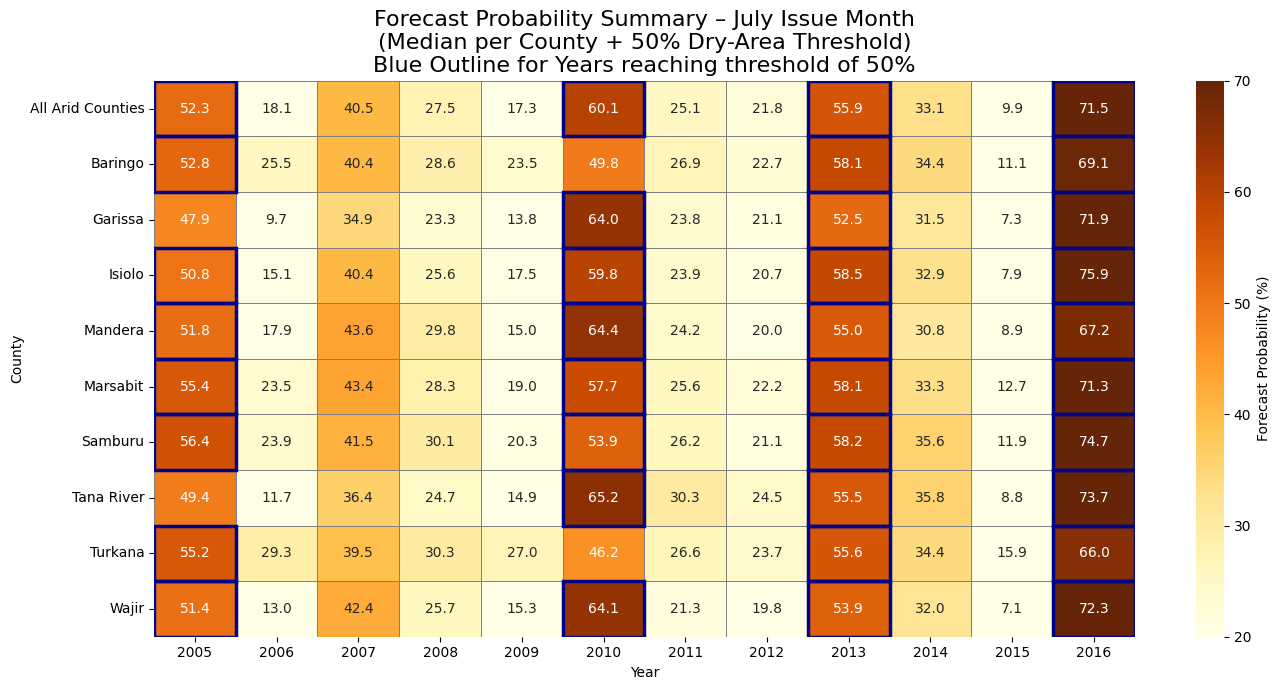

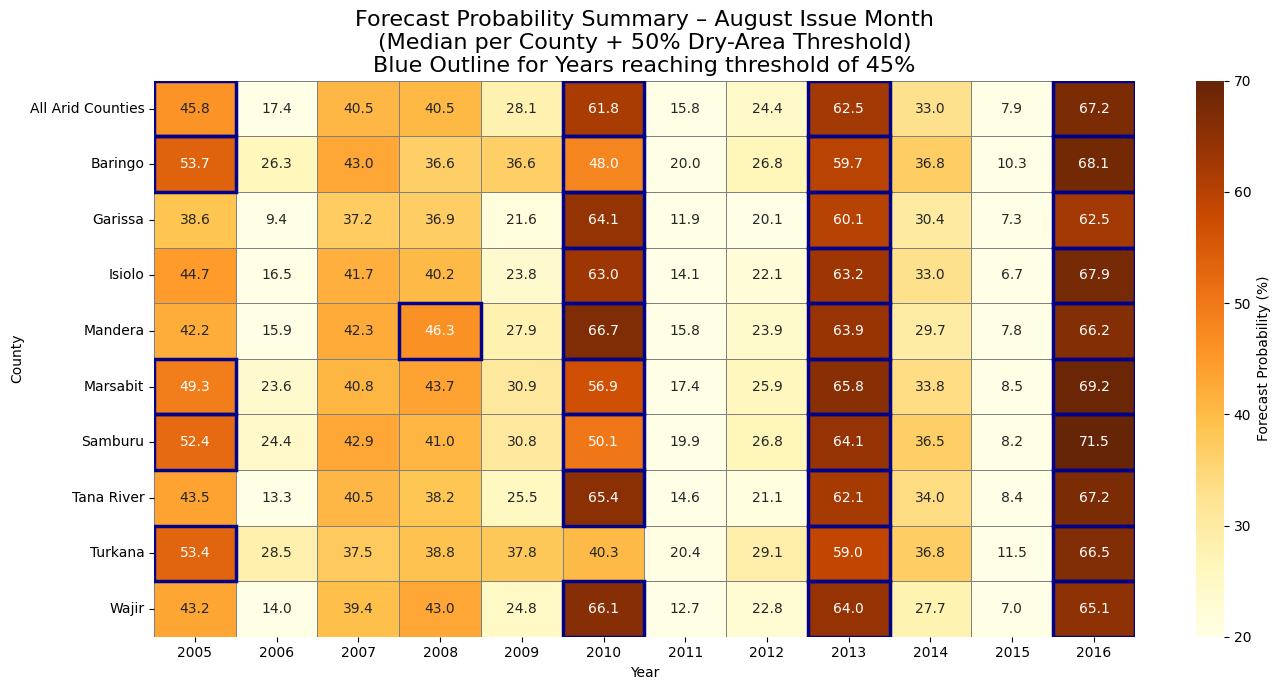

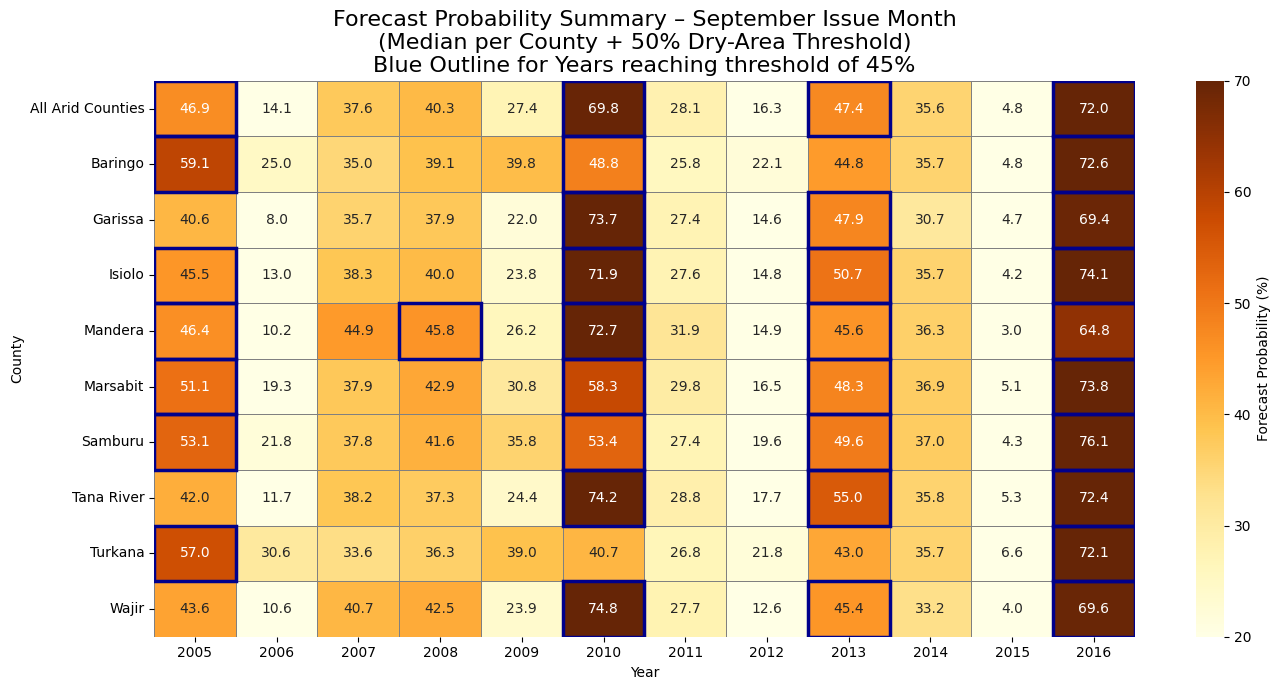

In [23]:
for issue_month in issue_months:

    df = final_df[
        (final_df["C"] == "2")
        & (final_df["clim_prob_type"] == "below")
        & (final_df["issue_month"] == issue_month)
    ].copy()

    gdf_points = gpd.GeoDataFrame(
        df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs=ken_geo_epsg
    )
    gdf_points = gdf_points.to_crs(ken_epsg)
    gdf_points["geometry"] = gdf_points.geometry.buffer(cell_size / 2, cap_style=3)
    gdf_points = gdf_points.to_crs(ken_geo_epsg)

    gdf_points["year"] = pd.to_datetime(gdf_points["T"]).dt.year

    # Spatial join with counties
    joined = gpd.sjoin(gdf_points, arid_counties, how="inner", predicate="intersects")

    # ------- 1) COUNTY-LEVEL median forecast probability -------
    avg_prob = joined.groupby(["adm1_name", "year"])["value"].median().reset_index()

    heat = avg_prob.pivot_table(index="adm1_name", columns="year", values="value")

    q = (
        joined.groupby("year")["value"]
        .quantile(quantile_RP3)
        .rename("All Arid Counties")
        .to_frame()
        .T  # put it as a row
    )

    # ------- 3) ADD to heatmap -------
    heat_with_row = pd.concat([q, heat], axis=0)

    # ------- 4) Plot -------
    plt.figure(figsize=(14, 7))
    sns.heatmap(
        heat_with_row,
        cmap="YlOrBr",
        linewidths=0.5,
        linecolor="gray",
        cbar_kws={"label": "Forecast Probability (%)"},
        annot=True,
        fmt=".1f",
        vmin=20,
        vmax=70,
    )
    threshold = 50 if issue_month == "July" else 45

    plt.title(
        f"Forecast Probability Summary – {issue_month} Issue Month\n"
        f"(Median per County + {round(100*(quantile_RP3))}% Dry-Area Threshold)\nBlue Outline for Years reaching threshold of {threshold}%",
        fontsize=16,
    )
    plt.xlabel("Year")
    plt.ylabel("County")

    ax = plt.gca()
    for i, county in enumerate(heat_with_row.index):
        for j, year in enumerate(heat_with_row.columns):
            val = heat_with_row.loc[county, year]
            if val >= threshold:
                ax.add_patch(
                    plt.Rectangle(
                        (j, i), 1, 1, fill=False, edgecolor="darkblue", linewidth=2.5
                    )
                )

    plt.tight_layout()
    plt.show()

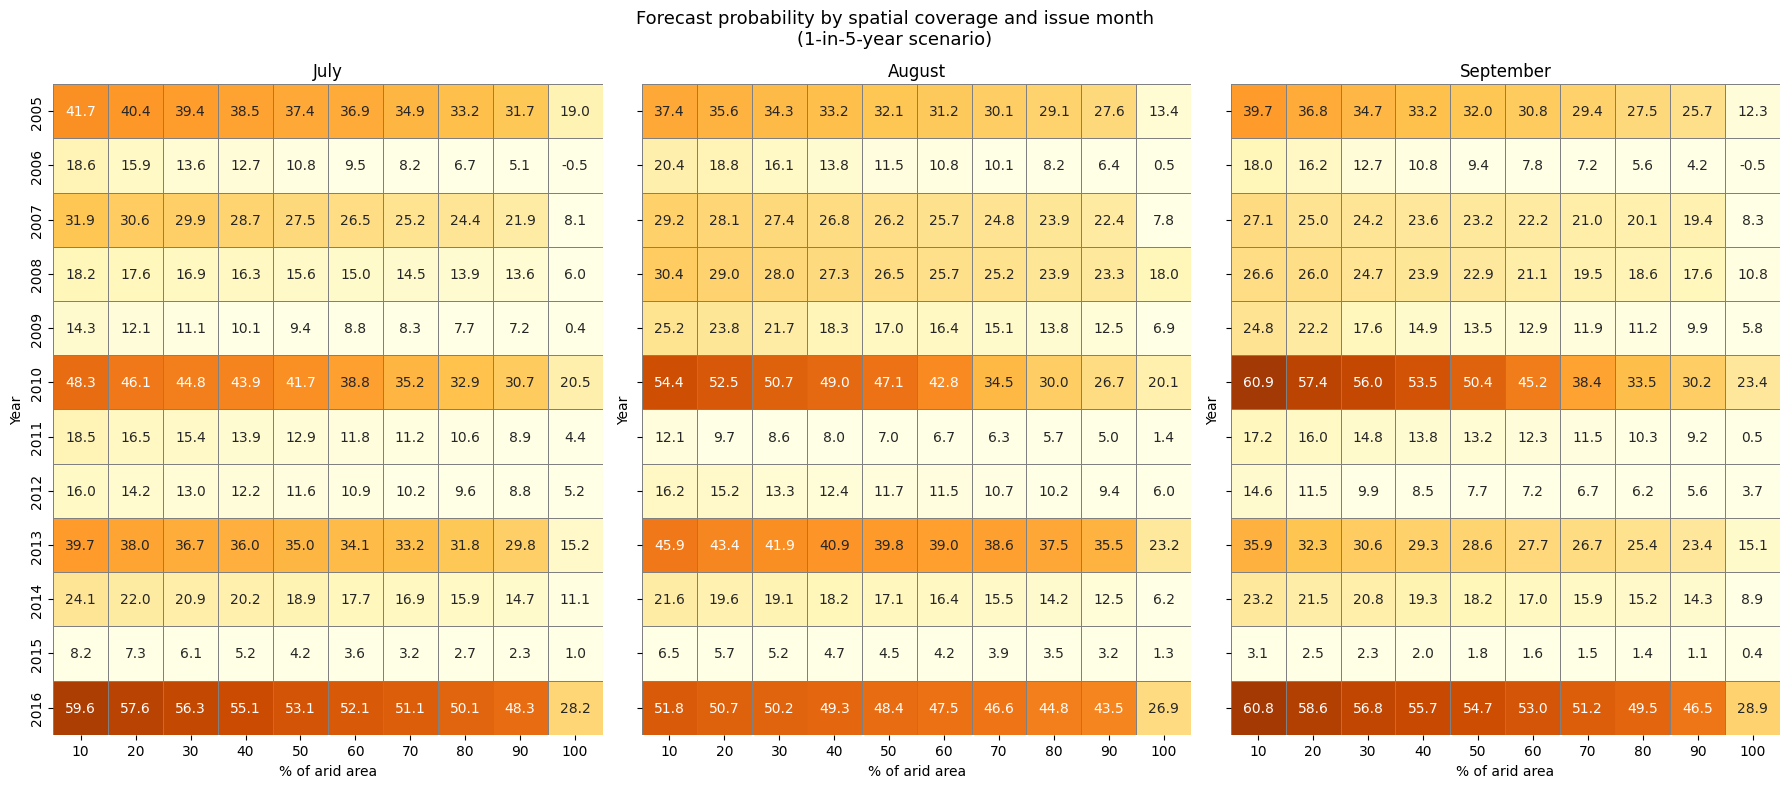

In [24]:
RP = 5  # 3 or 5
C = "1" if RP == 5 else "2"
area_bins = np.arange(0, 101, 10)
records = []

for issue_month in issue_months:

    df = final_df[
        (final_df["C"] == C)
        & (final_df["clim_prob_type"] == "below")
        & (final_df["issue_month"] == issue_month)
    ].copy()

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs=ken_geo_epsg,
    ).to_crs(ken_epsg)

    gdf["geometry"] = gdf.geometry.buffer(cell_size / 2, cap_style=3)
    gdf = gdf.to_crs(ken_geo_epsg)
    gdf["year"] = pd.to_datetime(gdf["T"]).dt.year

    joined = gpd.sjoin(gdf, arid_counties, how="inner", predicate="intersects")

    for year, sub in joined.groupby("year"):

        # sort pixels by driest first
        sub = sub.sort_values("value", ascending=False)

        for pct in area_bins:
            if pct == 0:
                continue

            n_cells = int(np.ceil(len(sub) * pct / 100))
            if n_cells == 0:
                continue

            # probability at that area coverage
            q = 1 - (pct / 100)  # <-- key point
            prob = sub["value"].quantile(q)
            # prob = sub.iloc[:n_cells]["value"].median()

            records.append(
                {
                    "issue_month": issue_month,
                    "year": year,
                    "pct_area": pct,
                    "probability": prob,
                }
            )

plot_df = pd.DataFrame(records)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 8), sharey=True)

for ax, issue_month in zip(axes, issue_months):

    sub = plot_df[plot_df["issue_month"] == issue_month]

    heat = (
        sub.pivot(index="year", columns="pct_area", values="probability")
        .reset_index()
        .sort_values("year")
        .set_index("year")
    )

    sns.heatmap(
        heat,
        ax=ax,
        cmap="YlOrBr",
        cbar=False,
        # cbar=ax == axes[-1],
        # cbar_kws={"label": "Forecast probability (%)"},
        linewidths=0.4,
        linecolor="gray",
        vmin=10,
        vmax=70,
        annot=True,
        fmt=".1f",
    )

    ax.set_title(issue_month)
    ax.set_xlabel("% of arid area")
    ax.set_ylabel("Year")

plt.suptitle(
    "Forecast probability by spatial coverage and issue month\n"
    f"(1-in-{RP}-year scenario)",
    fontsize=13,
)
plt.tight_layout()
plt.show()

In [25]:
# these activate for the same years. Checking the severity of each of the counties for each year
# Fetch ERA5 data for the specified woredas and date range
seasonal_rainfall = fetch_era5_data(
    arid_counties["adm1_src"].unique(), start_date=start_date, end_date=end_date
)
# adding month to the seasonal_rainfall dataframe for easier analysis
seasonal_rainfall["month"] = pd.to_datetime(seasonal_rainfall["valid_date"]).dt.month
seasonal_rainfall["year"] = pd.to_datetime(seasonal_rainfall["valid_date"]).dt.year
# extracting values for only the season months
seasonal_rainfall_months = seasonal_rainfall[
    seasonal_rainfall["month"].isin(season_months)
].copy()
seasonal_rainfall_months = seasonal_rainfall_months.merge(
    arid_counties[["adm1_name", "adm1_src"]], left_on="pcode", right_on="adm1_src"
)
seasonal_rainfall_months.loc[:, "month_name"] = seasonal_rainfall_months["month"].apply(
    lambda m: calendar.month_abbr[m]
)
# summing the mean column by year for all adm2_pcode
seasonal_rainfall_summed = (
    seasonal_rainfall_months.groupby(["month", "year"])
    .agg({"mean": "sum"})
    .reset_index()
)
seasonal_rainfall_county = (
    seasonal_rainfall_months.groupby(["adm1_name", "year"])
    .agg(season_total_mm=("mean", "sum"))
    .reset_index()
)

overall_seasonal = (
    seasonal_rainfall_months.groupby(["year"])
    .agg(season_total_mm=("mean", "sum"))
    .reset_index()
)
overall_seasonal["adm1_name"] = "All Arid Counties"
combined = pd.concat([overall_seasonal, seasonal_rainfall_county], ignore_index=True)

In [26]:
rp_df = (
    combined.groupby("adm1_name")
    .apply(helpers.compute_return_period, include_groups=False)
    .sort_values(["adm1_name", "season_total_mm"], ascending=[True, False])
)

rp_df.head()

year  season_total_mm  rank  return_period
adm1_name                                                       
All Arid Counties 0   1997       134.158743    29       1.034483
                  22  2019        97.852215    28       1.071429
                  9   2006        92.648372    27       1.111111
                  14  2011        88.202531    26       1.153846
                  26  2023        82.765448    25       1.200000

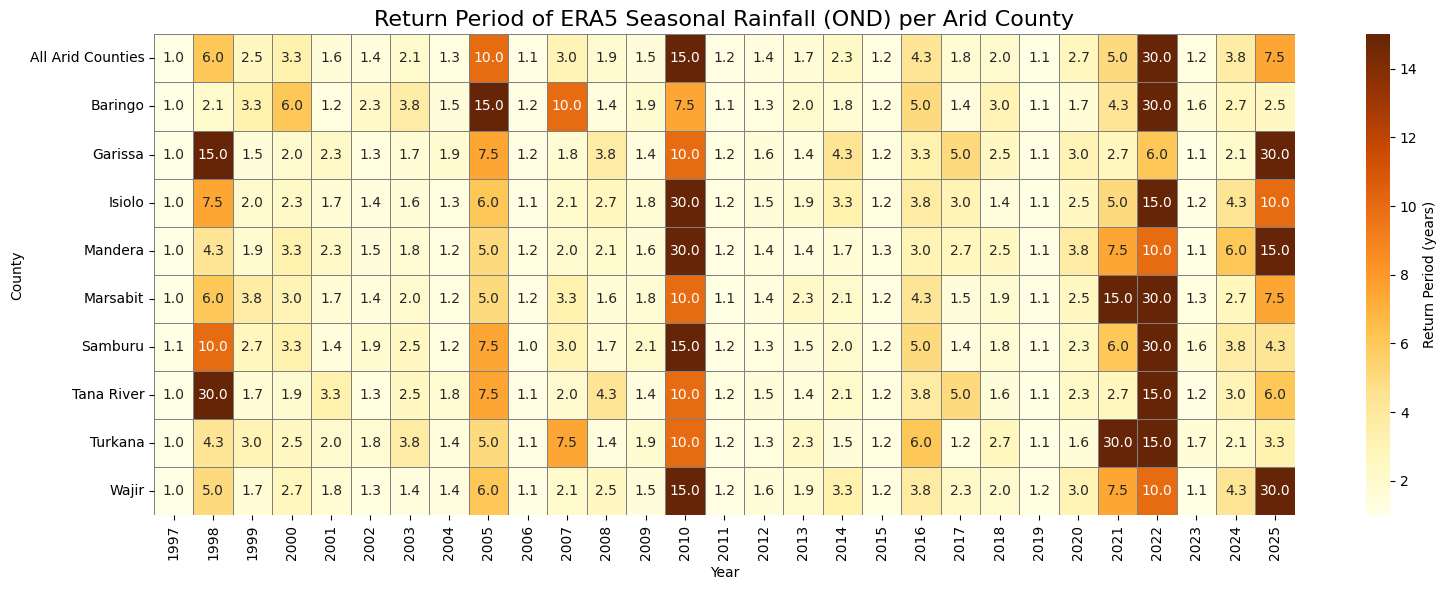

In [27]:
# Pivot to heatmap format
heat = rp_df.pivot_table(index="adm1_name", columns="year", values="return_period")

# Sort counties alphabetically but keep ALL_ARID on top
# heat = heat.reindex(sorted([c for c in heat.index if c != "ALL_ARID"]))

plt.figure(figsize=(16, 6))
sns.heatmap(
    heat,
    cmap="YlOrBr",  # reversed so high RP (rarer event) is darker
    vmin=1,
    vmax=15,
    linewidths=0.4,
    linecolor="gray",
    cbar_kws={"label": "Return Period (years)"},
    annot=True,
    fmt=".1f",
)

plt.title("Return Period of ERA5 Seasonal Rainfall (OND) per Arid County", fontsize=16)
plt.xlabel("Year")
plt.ylabel("County")

plt.tight_layout()
plt.show()